# 2 · PatchCore — EfficientNet-B4 Backbone (SOTA Benchmark)

No hyperparameter search needed. From the ResNet-18 ablation, we know:
- Best layers: `['layer2', 'layer3']` analog → EfficientNet `features[3]` + `features[5]`
- Best coreset_ratio: 0.05
- More images = better (use 5,500 for memory bank)
- `image_score='max'` outperforms `mean_topk`

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import pickle
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score

from src.dataset    import CrackDataset, load_splits
from src.train_utils import (build_patchcore_memory, patchcore_scores,
                              calibrate_threshold, compute_metrics, print_metrics)
from src.viz_utils  import (plot_roc_curve, plot_pr_curve,
                             plot_confusion_matrix, plot_score_histogram)


SPLITS_DIR       = 'splits'
RESULTS_DIR      = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

PREPROCESSING    = 'clahe'  
SPATIAL_SIZE     = (8, 8)    
PATCHES_PER_IMG  = 16        
CORESET_RATIO    = 0.05     
IMAGE_SCORE      = 'max'    
TOP_K_PATCHES    = 1
BANK_IMAGES      = 5_500     
MAX_EMBEDDINGS   = 50_000    
PROJECTION_DIM   = 128
PATCH_BATCH_SIZE = 2_048
BATCH_SIZE       = 32
SEED             = 42

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Device: cuda


## EfficientNet-B4 PatchCore Extractor

EfficientNet-B4 uses a `features` Sequential instead of named `layer1/2/3` attributes.
The semantic equivalents of ResNet's `layer2` / `layer3` are:

| ResNet-18 | EfficientNet-B4 | Channels | Spatial (for 256px input) |
|-----------|----------------|----------|---------------------------|
| `layer2`  | `features[3]`  | 48ch     | 32×32                     |
| `layer3`  | `features[5]`  | 112ch    | 16×16                     |

Feature dim = 48 + 112 = **160** (vs 384 for ResNet-18).
EfficientNet-B4 features are more discriminative despite lower channel count due to compound scaling.

In [ ]:
class PatchCoreExtractorEB4(nn.Module):
    _BLOCK_CHANNELS = {
        'features[1]':  24,
        'features[2]':  32,
        'features[3]':  48,
        'features[4]':  96,
        'features[5]': 112,
        'features[6]': 192,
        'features[7]': 320,
    }

    def __init__(
        self,
        feature_indices: list = None,   # e.g. [3, 5]
        spatial_size: tuple = (8, 8),
        pretrained: bool = True,
    ):
        super().__init__()
        if feature_indices is None:
            feature_indices = [3, 5]    # semantic equivalent of layer2 + layer3

        weights  = tvm.EfficientNet_B4_Weights.DEFAULT if pretrained else None
        backbone = tvm.efficientnet_b4(weights=weights)

        # Freeze all weights — PatchCore requires no gradient updates
        for param in backbone.parameters():
            param.requires_grad = False

        self.backbone        = backbone
        self.feature_indices = feature_indices
        self.spatial_size    = spatial_size
        self._hooks          = []
        self._features       = {}

        # Register hooks on the requested blocks
        for idx in feature_indices:
            block = backbone.features[idx]
            key   = f'features[{idx}]'
            handle = block.register_forward_hook(self._make_hook(key))
            self._hooks.append(handle)

    def _make_hook(self, name: str):
        def hook(module, input, output):
            self._features[name] = output   # (B, C, H, W)
        return hook

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        
        self._features.clear()
        with torch.no_grad():
            _ = self.backbone(x)
        pooled = []
        for idx in self.feature_indices:
            feat = self._features[f'features[{idx}]']
            pooled.append(feat.mean(dim=[2, 3]))    # (B, C)
        return torch.cat(pooled, dim=1)             # (B, feature_dim)

    def extract_patch_tokens(self, x: torch.Tensor) -> torch.Tensor:
        
        self._features.clear()
        with torch.no_grad():
            _ = self.backbone(x)
        patch_maps = []
        for idx in self.feature_indices:
            feat = self._features[f'features[{idx}]']           # (B, C, H, W)
            feat = F.adaptive_avg_pool2d(feat, self.spatial_size)  # (B, C, Hg, Wg)
            patch_maps.append(feat)
        merged = torch.cat(patch_maps, dim=1)                   # (B, sum_C, Hg, Wg)
        return merged.flatten(2).transpose(1, 2)                # (B, N_patches, sum_C)

    @property
    def feature_dim(self) -> int:
        return sum(self._BLOCK_CHANNELS[f'features[{i}]'] for i in self.feature_indices)

    def remove_hooks(self) -> None:
        for h in self._hooks:
            h.remove()
        self._hooks.clear()


# Sanity check
extractor = PatchCoreExtractorEB4(
    feature_indices=[3, 5],
    spatial_size=SPATIAL_SIZE,
    pretrained=True,
).to(DEVICE)

x_test   = torch.randn(2, 3, 256, 256).to(DEVICE)
f_global = extractor(x_test)
f_tokens = extractor.extract_patch_tokens(x_test)
print(f'Feature dim          : {extractor.feature_dim}  (vs 384 for ResNet-18)')
print(f'Global feature shape : {f_global.shape}')
print(f'Patch token shape    : {f_tokens.shape}   (B, N_patches={SPATIAL_SIZE[0]*SPATIAL_SIZE[1]}, D)')
print(f'All params frozen    : {all(not p.requires_grad for p in extractor.parameters())}')

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /home/fcp/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:07<00:00, 10.9MB/s]


Feature dim          : 160  (vs 384 for ResNet-18)
Global feature shape : torch.Size([2, 216])
Patch token shape    : torch.Size([2, 64, 216])   (B, N_patches=64, D)
All params frozen    : True


In [3]:
train_records, val_records, test_records = load_splits(SPLITS_DIR)

train_normal_ds = CrackDataset(train_records, preprocessing=PREPROCESSING,
                                augment=False, normal_only=True)
val_ds          = CrackDataset(val_records,   preprocessing=PREPROCESSING)
test_ds         = CrackDataset(test_records,  preprocessing=PREPROCESSING)

train_normal_loader = DataLoader(train_normal_ds, batch_size=BATCH_SIZE,
                                  shuffle=False, num_workers=0, pin_memory=False)
val_loader          = DataLoader(val_ds,           batch_size=BATCH_SIZE,
                                  shuffle=False, num_workers=0, pin_memory=False)
test_loader         = DataLoader(test_ds,          batch_size=BATCH_SIZE,
                                  shuffle=False, num_workers=0, pin_memory=False)

print(f'Train (normal only): {len(train_normal_ds):,}')
print(f'Val               : {len(val_ds):,}')
print(f'Test              : {len(test_ds):,}')
print(f'Preprocessing     : {PREPROCESSING}')

Train (normal only): 15,207
Val               : 3,650
Test              : 3,651
Preprocessing     : clahe


## Build Memory Bank

In [4]:
print('Building EfficientNet-B4 PatchCore memory bank...')
print(f'  Training images cap : {BANK_IMAGES:,}')
print(f'  Max embeddings      : {MAX_EMBEDDINGS:,}')
print(f'  Coreset ratio       : {CORESET_RATIO}')
print(f'  Feature dim         : {extractor.feature_dim}')
print()

memory_bank = build_patchcore_memory(
    extractor,
    train_normal_loader,
    DEVICE,
    coreset_ratio     = CORESET_RATIO,
    patches_per_image = PATCHES_PER_IMG,
    max_images        = BANK_IMAGES,
    max_embeddings    = MAX_EMBEDDINGS,
    projection_dim    = PROJECTION_DIM,
    seed              = SEED,
)
print(f'Memory bank: {memory_bank.shape}  ({memory_bank.nbytes / 1e6:.1f} MB)')

# Save memory bank
bank_path = os.path.join(RESULTS_DIR, 'patchcore_efficientnet_b4_bank.pkl')
with open(bank_path, 'wb') as f:
    pickle.dump({
        'memory_bank'     : memory_bank,
        'feature_indices' : extractor.feature_indices,
        'spatial_size'    : extractor.spatial_size,
        'preprocessing'   : PREPROCESSING,
        'coreset_ratio'   : CORESET_RATIO,
        'bank_images'     : BANK_IMAGES,
        'max_embeddings'  : MAX_EMBEDDINGS,
    }, f)
print(f'Memory bank saved → {bank_path}')

Building EfficientNet-B4 PatchCore memory bank...
  Training images cap : 5,500
  Max embeddings      : 50,000
  Coreset ratio       : 0.05
  Feature dim         : 160

  Images processed: 5,500
  Patch descriptors: 50,000 → coreset: 2,500 (5%)
Memory bank: (2500, 216)  (2.2 MB)
Memory bank saved → results/patchcore_efficientnet_b4_bank.pkl


## Calibrate Threshold on Validation Set

Computing validation anomaly scores...
Val AUROC: 0.7649
Best threshold τ = 0.820621  (val F1 = 0.3659)


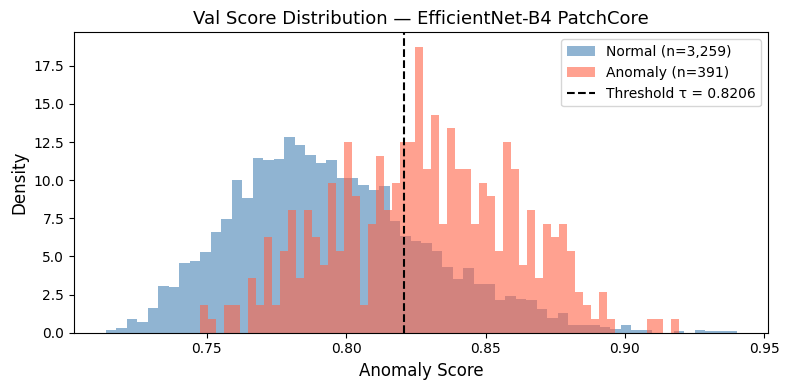

In [5]:
print('Computing validation anomaly scores...')
val_scores, val_labels = patchcore_scores(
    extractor, val_loader, memory_bank, DEVICE,
    image_score      = IMAGE_SCORE,
    top_k_patches    = TOP_K_PATCHES,
    patch_batch_size = PATCH_BATCH_SIZE,
)

val_auroc = roc_auc_score(val_labels, val_scores)
print(f'Val AUROC: {val_auroc:.4f}')

tau, val_f1 = calibrate_threshold(val_scores, val_labels)
print(f'Best threshold τ = {tau:.6f}  (val F1 = {val_f1:.4f})')

ax = plot_score_histogram(val_scores, val_labels, threshold=tau,
                           title='Val Score Distribution — EfficientNet-B4 PatchCore')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'eb4_val_score_dist.png'), dpi=120, bbox_inches='tight')
plt.show()

## Test Set Evaluation

In [6]:
print('Computing test anomaly scores...')
test_scores, test_labels = patchcore_scores(
    extractor, test_loader, memory_bank, DEVICE,
    image_score      = IMAGE_SCORE,
    top_k_patches    = TOP_K_PATCHES,
    patch_batch_size = PATCH_BATCH_SIZE,
)

metrics = compute_metrics(test_scores, test_labels, tau)
print_metrics(metrics, model_name='PatchCore (EfficientNet-B4)')

results = {
    'scores'          : test_scores,
    'labels'          : test_labels,
    'threshold'       : tau,
    'val_auroc'       : val_auroc,
    'val_f1'          : val_f1,
    'backbone'        : 'efficientnet_b4',
    'feature_indices' : extractor.feature_indices,
    'preprocessing'   : PREPROCESSING,
    'coreset_ratio'   : CORESET_RATIO,
    'memory_bank_shape': memory_bank.shape,
    **{k: v for k, v in metrics.items() if k != 'preds'},
}
with open(os.path.join(RESULTS_DIR, 'results_patchcore_eb4.pkl'), 'wb') as f:
    pickle.dump(results, f)
print('Results saved.')

Computing test anomaly scores...
[PatchCore (EfficientNet-B4)] AUROC: 0.7744  AUPRC: 0.2656  F1: 0.3755
  Confusion matrix:
    TN=  2578  FP=   682
    FN=   143  TP=   248
Results saved.


## Visualisations

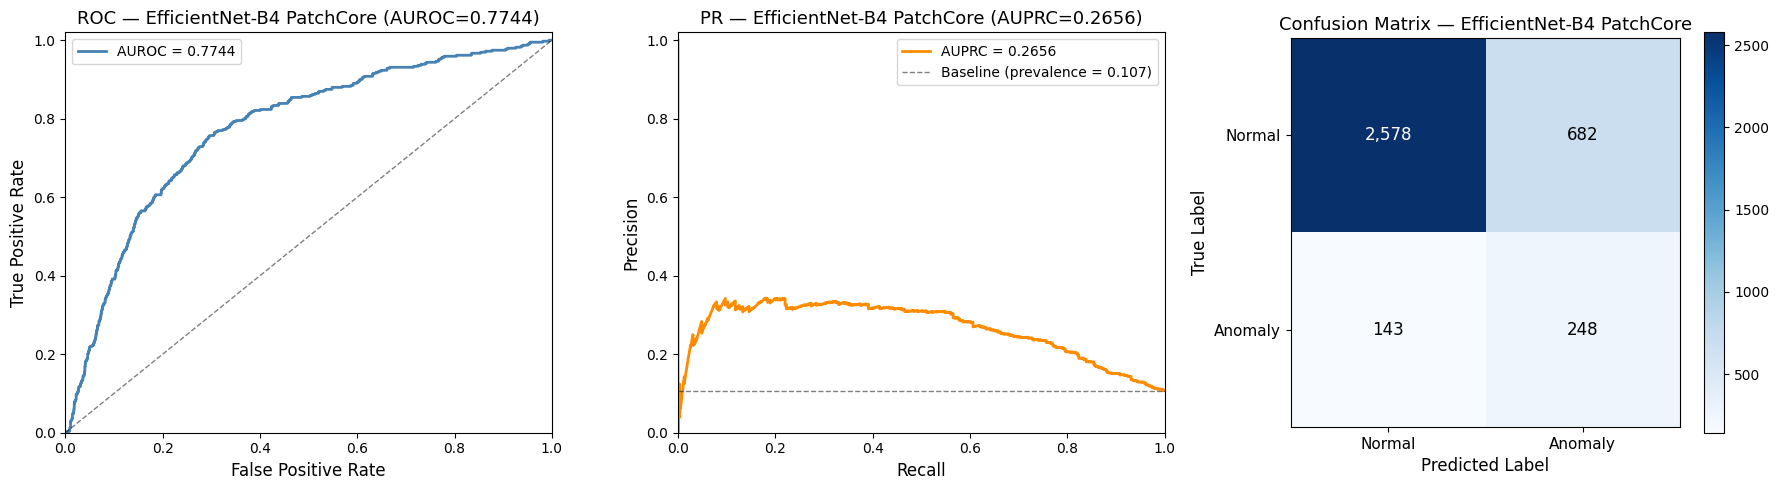

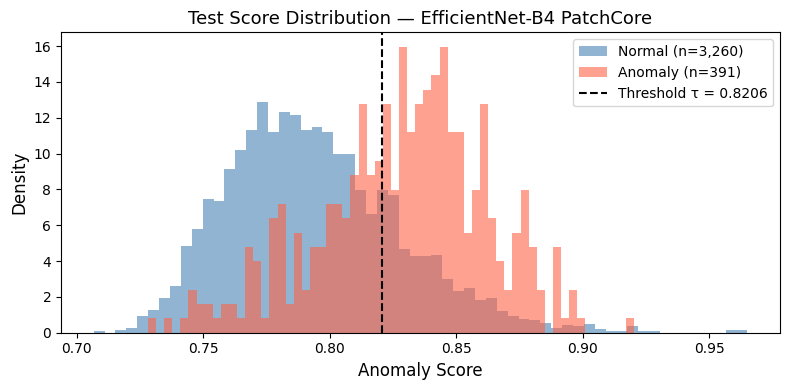

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_roc_curve(test_scores, test_labels, metrics['auroc'],
               title=f'ROC — EfficientNet-B4 PatchCore (AUROC={metrics["auroc"]:.4f})',
               ax=axes[0])
plot_pr_curve(test_scores, test_labels, metrics['auprc'],
              title=f'PR — EfficientNet-B4 PatchCore (AUPRC={metrics["auprc"]:.4f})',
              ax=axes[1])
plot_confusion_matrix(metrics['cm'],
                      title='Confusion Matrix — EfficientNet-B4 PatchCore',
                      ax=axes[2])
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'eb4_test_metrics.png'), dpi=120, bbox_inches='tight')
plt.show()

ax = plot_score_histogram(test_scores, test_labels, threshold=tau,
                           title='Test Score Distribution — EfficientNet-B4 PatchCore')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'eb4_test_score_dist.png'), dpi=120, bbox_inches='tight')
plt.show()

## CLAHE vs None Preprocessing

CLAHE (contrast-limited adaptive histogram equalisation) helps in SVDD.
This cell checks whether it also helps for EfficientNet-B4 PatchCore.

In [ ]:


train_normal_none = CrackDataset(train_records, preprocessing='none',
                                  augment=False, normal_only=True)
val_none          = CrackDataset(val_records,   preprocessing='none')
train_loader_none = DataLoader(train_normal_none, batch_size=BATCH_SIZE,
                                shuffle=False, num_workers=0)
val_loader_none   = DataLoader(val_none, batch_size=BATCH_SIZE,
                                shuffle=False, num_workers=0)

ext_none = PatchCoreExtractorEB4(feature_indices=[3, 5],
                                  spatial_size=SPATIAL_SIZE, pretrained=True).to(DEVICE)
bank_none = build_patchcore_memory(
    ext_none, train_loader_none, DEVICE,
    coreset_ratio=CORESET_RATIO, patches_per_image=PATCHES_PER_IMG,
    max_images=BANK_IMAGES, max_embeddings=MAX_EMBEDDINGS,
    projection_dim=PROJECTION_DIM, seed=SEED)
vs_none, vl_none = patchcore_scores(ext_none, val_loader_none, bank_none, DEVICE,
                                     image_score='max', patch_batch_size=PATCH_BATCH_SIZE)
print(f'Val AUROC — none : {roc_auc_score(vl_none, vs_none):.4f}')
print(f'Val AUROC — clahe: {val_auroc:.4f}')
ext_none.remove_hooks()


  Images processed: 5,500
  Patch descriptors: 50,000 → coreset: 2,500 (5%)
Val AUROC — none : 0.7850
Val AUROC — clahe: 0.7649


In [10]:
extractor.remove_hooks()
torch.cuda.empty_cache()

## Results and Issues
PatchCore achieved a test AUROC of 0.7744 and AUPRC of 0.2656, with 2578 TN, 682 FP, 143 FN, and 248 TP. This clearly outperformed all AE variants (~0.61 AUROC) and image-level SVDD (~0.64-0.67). Importantly, this was achieved with no training: PatchCore only builds a memory bank of normal patch features and scores each test image by nearest-neighbor distance.

Issues
PatchCore works better because it asks whether a patch looks like anything seen in normal data, rather than trying to reconstruct it or compress the whole image into one embedding. This makes it much more robust for sparse, localised anomalies like cracks. Raw images also outperformed CLAHE on EfficientNet-B4, suggesting the backbone features were already strong enough without preprocessing.

The main remaining issue is false positives on rough but normal concrete, which can still look far from the normal memory bank. So while PatchCore is the best normal-only method so far, its remaining errors are mostly due to ambiguous texture rather than unstable training.

This also raises a question: if we introduce even a small number of labeled crack examples during training, can we do better? PatchCore's 0.77 ceiling represents the best possible performance from normal-only information. Any improvement beyond this would have to come from crack-side knowledge.
